# Этап 4 — Предсказание кухни (community detection)

**Задача (курс SNA):** community detection → классификация кухни.

1. Leiden на графе ингредиентов `I` → сообщества.
2. Рецепт = распределение ингредиентов по сообществам.
3. Логистическая регрессия предсказывает кухню (proxy-метка из URL).
4. **t-SNE** эмбеддингов ингредиентов — визуализация кластеров.

кластеризуем **ингредиенты**, не блюда.

**Метки кухни:** в RecipeNLG subset почти все URL → american. Поэтому используем proxy: характерные ингредиенты (`label_cuisine` в `data_utils.py`) + стратифицированная выборка.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import igraph as ig
import leidenalg

from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

from data_utils import load_recipes_stratified, recipe_community_vector, cuisine_counts
from ingredient_ru import ru, ru_list

OUT = Path('output_graphs')
DATA = Path('full_dataset.csv')
if not DATA.exists():
    DATA = Path('data_sample.csv')

SEED = 42
PER_CUISINE = 1200 if DATA.name == 'full_dataset.csv' else 200
print('Готово')

Готово


## 4.1 Leiden — сообщества ингредиентов

In [2]:
I = nx.read_graphml(OUT / 'ingredient_graph.graphml')

nodes = list(I.nodes())
idx = {n: i for i, n in enumerate(nodes)}
edges = [(idx[u], idx[v]) for u, v in I.edges()]
g = ig.Graph(n=len(nodes), edges=edges, directed=False)

part = leidenalg.find_partition(g, leidenalg.ModularityVertexPartition, seed=SEED)
comm = {nodes[i]: part.membership[i] for i in range(len(nodes))}
n_comm = max(part.membership) + 1

print(f'Сообществ: {n_comm}, modularity = {part.modularity:.3f}')
some = part.membership[0]
members = [nodes[i] for i, m in enumerate(part.membership) if m == some][:8]
print('Пример сообщества:', ', '.join(ru_list(members)))

Сообществ: 7, modularity = 0.243
Пример сообщества: rigatoni, italian bread, corn tortilla, ground lean pork, rice wine vinegar, lean ground beef, seasoning mix, generous


## 4.2 Стратифицированная выборка рецептов по кухням

In [3]:
df = load_recipes_stratified(DATA, per_cuisine=PER_CUISINE, min_ingredients=3)
df = df[df['ingredients'].apply(lambda xs: any(x in comm for x in xs))].reset_index(drop=True)

print(f'Рецептов: {len(df):,}')
print('Распределение кухонь:')
for c, n in cuisine_counts(df).most_common():
    print(f'  {c:12s} {n:5d}')

Рецептов: 8,400
Распределение кухонь:
  american      1200
  chinese       1200
  italian       1200
  mexican       1200
  indian        1200
  french        1200
  japanese      1200


## 4.3 Вектор рецепта и классификатор

Точность: 0.356
              precision    recall  f1-score   support

    american       0.54      0.54      0.54       240
     chinese       0.29      0.19      0.23       240
      french       0.23      0.10      0.14       240
      indian       0.30      0.34      0.32       240
     italian       0.38      0.64      0.47       240
    japanese       0.14      0.05      0.07       240
     mexican       0.37      0.63      0.47       240

    accuracy                           0.36      1680
   macro avg       0.32      0.36      0.32      1680
weighted avg       0.32      0.36      0.32      1680



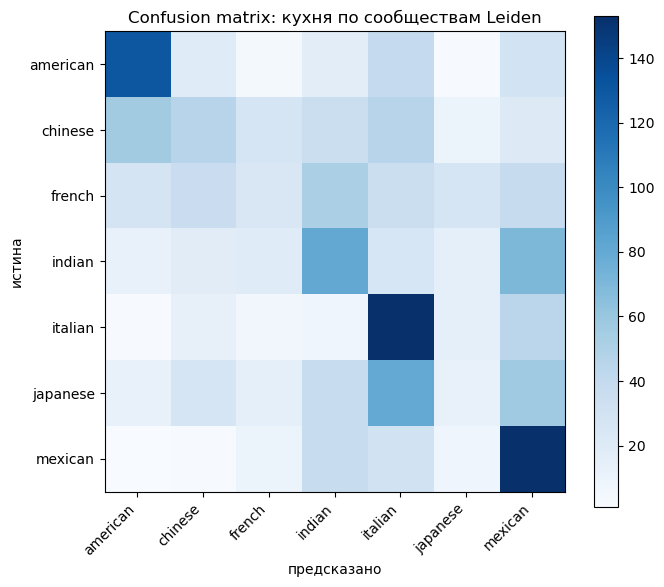

In [4]:
X = np.vstack([
    recipe_community_vector(ings, comm, n_comm)
    for ings in df['ingredients']
])
y_cuisine = df['cuisine'].astype(str).values

if len(set(y_cuisine)) < 2:
    print('Нужно больше кухонь — положите full_dataset.csv в корень проекта.')
else:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y_cuisine, test_size=0.2, random_state=SEED, stratify=y_cuisine,
    )
    clf = LogisticRegression(max_iter=2000, solver='lbfgs')
    clf.fit(X_tr, y_tr)
    pred = clf.predict(X_te)
    print(f'Точность: {accuracy_score(y_te, pred):.3f}')
    print(classification_report(y_te, pred))

    labels = sorted(set(y_cuisine))
    cm = confusion_matrix(y_te, pred, labels=labels)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap='Blues')
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    ax.set_xlabel('предсказано'); ax.set_ylabel('истина')
    ax.set_title('Confusion matrix: кухня по сообществам Leiden')
    plt.tight_layout()
    plt.savefig(OUT / 'cuisine_confusion.png', dpi=120)
    plt.show()

## 4.4 t-SNE эмбеддингов ингредиентов

Признаки: degree, pagerank, clustering + one-hot сообщества Leiden (2D) .

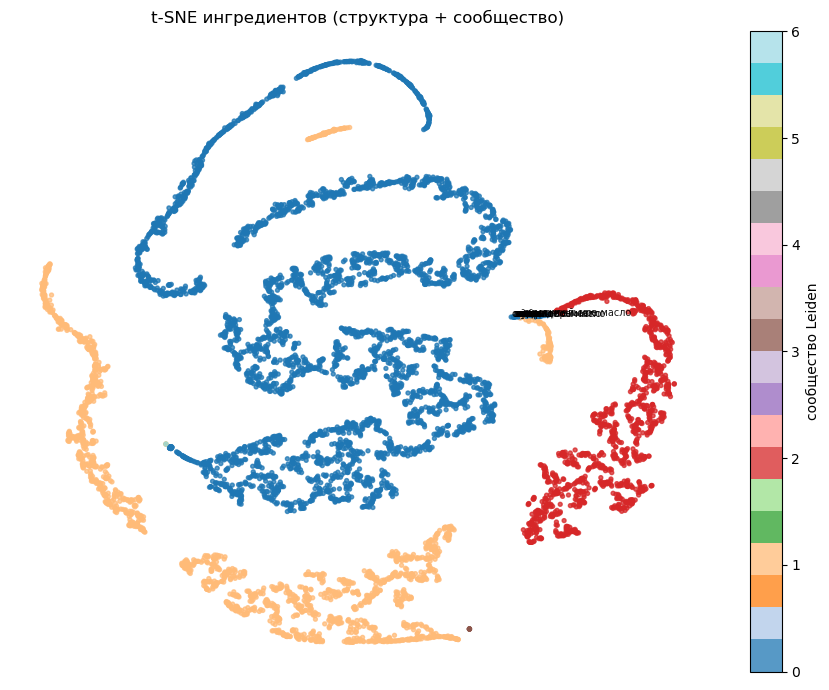

In [5]:
ing_nodes = list(I.nodes())
pr = nx.pagerank(I, weight='weight', alpha=0.85)
cl = nx.clustering(I, weight='weight')
deg = dict(I.degree())

struct = np.array([
    [deg.get(n, 0), pr.get(n, 0.0), cl.get(n, 0.0)]
    for n in ing_nodes
], dtype=float)
struct = (struct - struct.mean(0)) / (struct.std(0) + 1e-9)

comm_oh = np.zeros((len(ing_nodes), n_comm))
for i, n in enumerate(ing_nodes):
    c = comm.get(n, 0)
    comm_oh[i, c] = 1.0

X_ing = np.hstack([struct, comm_oh])
coords = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000).fit_transform(X_ing)
colors = [comm.get(n, 0) for n in ing_nodes]

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(coords[:, 0], coords[:, 1], c=colors, cmap='tab20', s=8, alpha=0.75)
plt.colorbar(sc, ax=ax, label='сообщество Leiden')

ing_idx = {n: i for i, n in enumerate(ing_nodes)}
top = sorted(ing_nodes, key=lambda n: deg.get(n, 0), reverse=True)[:15]
for n in top:
    ax.annotate(ru(n), coords[ing_idx[n]], fontsize=7, alpha=0.9)

ax.set_title('t-SNE ингредиентов (структура + сообщество)')
ax.axis('off')
plt.tight_layout()
plt.savefig(OUT / 'cuisine_tsne.png', dpi=120)
plt.show()

## 4.5 Layout графа (community-aware spring layout)

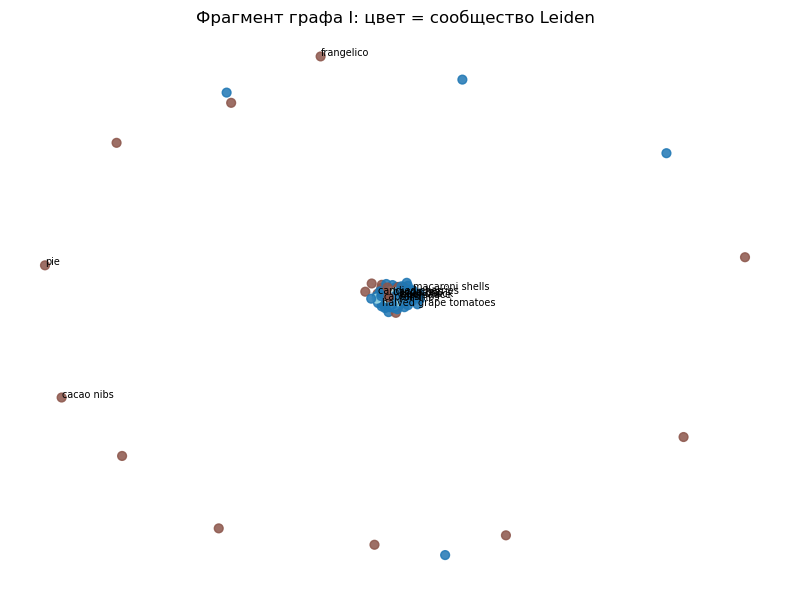

In [6]:
sub_nodes = [n for n, d in I.degree() if d >= 30][:120]
H = I.subgraph(sub_nodes).copy()
pos = nx.spring_layout(H, seed=SEED)
node_colors = [comm.get(n, 0) for n in H.nodes()]

plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(H, pos, node_color=node_colors, cmap=plt.cm.tab20, node_size=40, alpha=0.85)
nx.draw_networkx_edges(H, pos, alpha=0.08)
for n in list(H.nodes())[:12]:
    xi, yi = pos[n]
    plt.text(xi, yi, ru(n), fontsize=7)
plt.title('Фрагмент графа I: цвет = сообщество Leiden')
plt.axis('off')
plt.tight_layout()
plt.savefig(OUT / 'cuisine_communities.png', dpi=120)
plt.show()

## 4.6 Примеры предсказаний (на русском)

In [7]:
if df['cuisine'].nunique() >= 2:
    proba = clf.predict_proba(X)
    classes = clf.classes_
    for i in range(min(5, len(df))):
        j = int(np.argmax(proba[i]))
        ings = [x for x in df.loc[i, 'ingredients'] if x in comm][:8]
        print(f"\n{df.loc[i, 'title'][:60]}")
        print(f"  истина: {df.loc[i, 'cuisine']}  →  модель: {classes[j]} ({proba[i,j]:.2f})")
        print(f"  ингредиенты: {', '.join(ru_list(ings))}")


No-Bake Nut Cookies
  истина: american  →  модель: american (0.70)
  ингредиенты: коричневый сахар, молоко, ваниль, орехи, сливочное масло

Jewell Ball'S Chicken
  истина: american  →  модель: mexican (0.48)
  ингредиенты: говядина, chicken breasts, cream of mushroom soup, сметана

Creamy Corn
  истина: american  →  модель: chinese (0.23)
  ингредиенты: frozen corn, сливочный сыр, сливочное масло, garlic powder, соль, перец

Chicken Funny
  истина: american  →  модель: mexican (0.21)
  ингредиенты: курица, chicken gravy, cream of mushroom soup, shredded cheese

Reeses Cups(Candy)  
  истина: american  →  модель: american (0.80)
  ингредиенты: арахисовая паста, graham cracker crumbs, сливочное масло, сахарная пудра, chocolate chips


In [8]:
with open(OUT / 'ingredient_communities.json', 'w', encoding='utf-8') as f:
    json.dump({k: int(v) for k, v in comm.items()}, f, ensure_ascii=False)
print('Сохранено: ingredient_communities.json')

Сохранено: ingredient_communities.json


## 4.7 Построение двудольного графа G из выборки рецептов

Для GraphSAGE и HeteroGAT нам нужен граф вида рецепт ↔ ингредиент.  
Если `bipartite_sample.graphml` уже существует — загрузим его.  
Иначе — строим на лету из `df` (текущая выборка по кухням).


In [9]:
import importlib
import gnn_cuisine_classification
importlib.reload(gnn_cuisine_classification)
from gnn_cuisine_classification import (
    train_graphsage_cuisine,
    train_hetgat_cuisine,
)

# Загружаем структурные признаки ингредиентов из nb02
feat_df = pd.read_csv(OUT / 'node_features_structural.csv', index_col='ingredient')
print(f'Признаки: {feat_df.shape[1]} фич, {len(feat_df):,} ингредиентов')


Признаки: 7 фич, 7,199 ингредиентов


In [10]:
# Строим двудольный граф G из текущей выборки рецептов (df)
G_small = nx.Graph()

recipe_ids_gnn = []
labels_gnn     = []

for i, row in df.iterrows():
    rid = f'recipe::{i}'
    G_small.add_node(rid, ntype='recipe')
    for ing in row['ingredients']:
        if ing in I:
            G_small.add_node(ing, ntype='ingredient')
            G_small.add_edge(rid, ing)
    recipe_ids_gnn.append(rid)
    labels_gnn.append(row['cuisine'])

print(f'Рецептов: {len(recipe_ids_gnn)}, кухонь: {len(set(labels_gnn))}')
print(f'Граф G: {G_small.number_of_nodes():,} узлов, {G_small.number_of_edges():,} рёбер')


Рецептов: 8400, кухонь: 7
Граф G: 11,694 узлов, 86,488 рёбер


## 4.8 GraphSAGE baseline

GraphSAGE агрегирует признаки соседей и учит эмбеддинг каждого рецепта.  
Модель: 2 слоя SAGEConv → линейный классификатор.  
Это **обязательный baseline**, о котором говорил Илья.


In [11]:
gs_result = train_graphsage_cuisine(
    G_nx       = G_small,
    recipe_ids = recipe_ids_gnn,
    labels     = labels_gnn,
    I_nx       = I,
    feat_df    = feat_df,
    hidden     = 128,
    epochs     = 100,
    lr         = 3e-3,
    test_ratio = 0.2,
    seed       = SEED,
    verbose    = True,
)

print('\n── GraphSAGE ──')
print(f'Точность: {gs_result.accuracy:.3f}')
print(f'F1 macro: {gs_result.f1:.3f}')
print(f'AUC:      {gs_result.auc:.3f}')
print()
print(gs_result.report)


  [GraphSAGE] epoch  20  loss=1.7775  test_acc=0.304
  [GraphSAGE] epoch  40  loss=1.6342  test_acc=0.339
  [GraphSAGE] epoch  60  loss=1.5050  test_acc=0.422
  [GraphSAGE] epoch  80  loss=1.4019  test_acc=0.496
  [GraphSAGE] epoch 100  loss=1.2685  test_acc=0.551

── GraphSAGE ──
Точность: 0.551
F1 macro: 0.531
AUC:      0.887

              precision    recall  f1-score   support

    american       0.66      0.69      0.68       219
     chinese       0.63      0.62      0.63       245
      french       0.71      0.10      0.17       252
      indian       0.48      0.60      0.54       209
     italian       0.50      0.67      0.57       256
    japanese       0.66      0.64      0.65       258
     mexican       0.42      0.55      0.47       241

    accuracy                           0.55      1680
   macro avg       0.58      0.55      0.53      1680
weighted avg       0.58      0.55      0.53      1680



## 4.9 HeteroGAT — финальная модель

HeteroGAT работает с **гетерогенным графом**: отдельные типы узлов для рецептов и ингредиентов,  
отдельные веса для каждого типа рёбер. Это позволяет модели различать  
«рецепт содержит ингредиент» и «ингредиент входит в рецепт».

Та же архитектура используется для задачи 3 (real vs fake).


In [12]:
hg_result = train_hetgat_cuisine(
    G_nx       = G_small,
    recipe_ids = recipe_ids_gnn,
    labels     = labels_gnn,
    I_nx       = I,
    feat_df    = feat_df,
    hidden     = 128,
    heads      = 4,
    epochs     = 100,
    lr         = 3e-3,
    test_ratio = 0.2,
    seed       = SEED,
    verbose    = True,
)

print('\n── HeteroGAT ──')
print(f'Точность: {hg_result.accuracy:.3f}')
print(f'F1 macro: {hg_result.f1:.3f}')
print(f'AUC:      {hg_result.auc:.3f}')
print()
print(hg_result.report)


  [HeteroGAT] epoch  20  loss=1.8558  test_acc=0.332
  [HeteroGAT] epoch  40  loss=1.6004  test_acc=0.412
  [HeteroGAT] epoch  60  loss=1.4002  test_acc=0.501
  [HeteroGAT] epoch  80  loss=1.3112  test_acc=0.585
  [HeteroGAT] epoch 100  loss=1.1865  test_acc=0.646

── HeteroGAT ──
Точность: 0.646
F1 macro: 0.638
AUC:      0.904

              precision    recall  f1-score   support

    american       0.82      0.56      0.67       219
     chinese       0.59      0.94      0.73       245
      french       0.62      0.63      0.63       252
      indian       0.68      0.51      0.58       209
     italian       0.55      0.66      0.60       256
    japanese       0.84      0.77      0.80       258
     mexican       0.54      0.41      0.47       241

    accuracy                           0.65      1680
   macro avg       0.66      0.64      0.64      1680
weighted avg       0.66      0.65      0.64      1680



## 4.10 Сравнение всех моделей


,Модель,Точность,F1 macro,AUC,Описание
0,LogReg (community-vector),0.356,0.320,NaN,Leiden communities → LogReg
1,GraphSAGE,0.551,0.531,0.887,"2-layer SAGEConv, homogeneous graph"
2,HeteroGAT,0.646,0.638,0.904,"2-layer GATConv, heterogeneous graph"


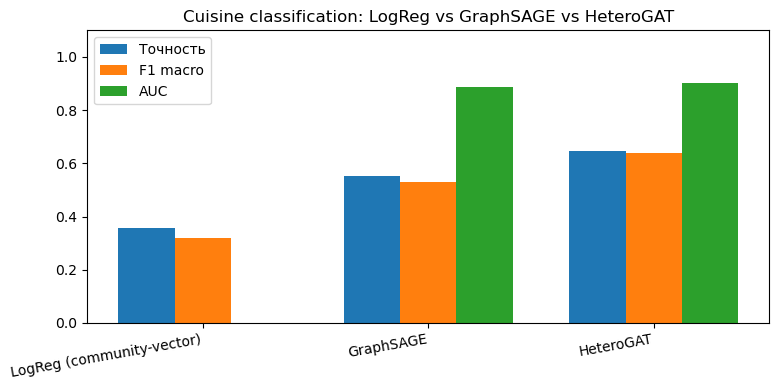

In [13]:
# baseline (из ячейки 4.3)
baseline_acc = accuracy_score(y_te, pred) if 'y_te' in dir() else float('nan')

comparison = pd.DataFrame([
    {
        'Модель':   'LogReg (community-vector)',
        'Точность': baseline_acc,
        'F1 macro': f1_score(y_te, pred, average='macro', zero_division=0) if 'y_te' in dir() else float('nan'),
        'AUC':      float('nan'),
        'Описание': 'Leiden communities → LogReg',
    },
    {
        'Модель':   'GraphSAGE',
        'Точность': gs_result.accuracy,
        'F1 macro': gs_result.f1,
        'AUC':      gs_result.auc,
        'Описание': '2-layer SAGEConv, homogeneous graph',
    },
    {
        'Модель':   'HeteroGAT',
        'Точность': hg_result.accuracy,
        'F1 macro': hg_result.f1,
        'AUC':      hg_result.auc,
        'Описание': '2-layer GATConv, heterogeneous graph',
    },
])
display(comparison.round(3))

# Бар-чарт
models = comparison['Модель']
x = np.arange(len(models))
w = 0.25
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w,   comparison['Точность'], w, label='Точность')
ax.bar(x,       comparison['F1 macro'], w, label='F1 macro')
ax.bar(x + w,   comparison['AUC'],      w, label='AUC')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=10, ha='right')
ax.set_ylim(0, 1.1)
ax.set_title('Cuisine classification: LogReg vs GraphSAGE vs HeteroGAT')
ax.legend()
plt.tight_layout()
plt.savefig(OUT / 'cuisine_model_comparison.png', dpi=120)
plt.show()


## 4.11 t-SNE обученных эмбеддингов рецептов (HeteroGAT)

В отличие от §4.4 (t-SNE **входных** признаков ингредиентов), здесь визуализируем **эмбеддинги рецептов, выученные моделью** HeteroGAT (`hg_result.recipe_emb`), и красим точки по истинной кухне — видно, насколько модель разносит кухни в пространстве представлений.

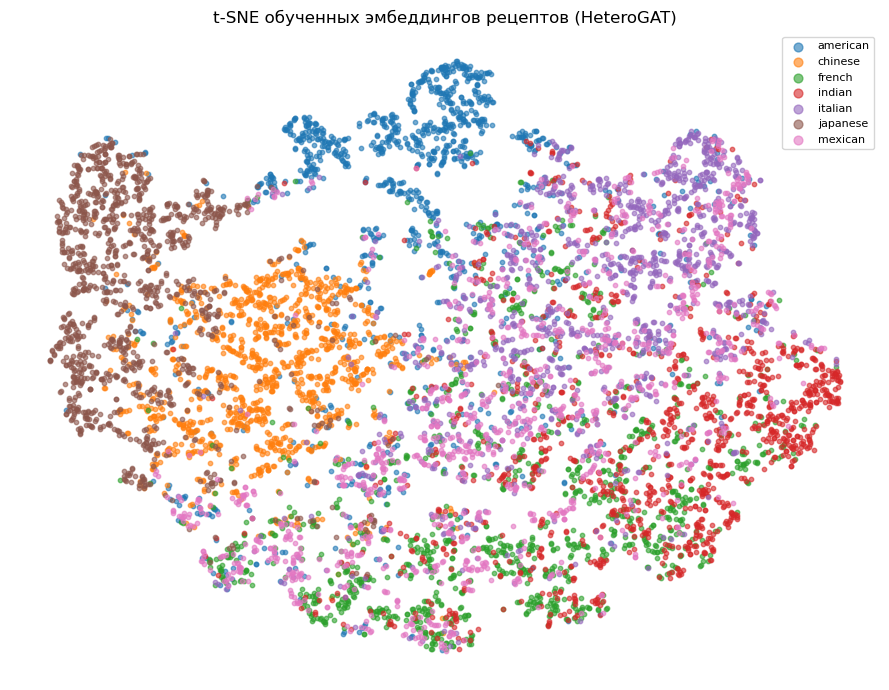

In [14]:
from sklearn.manifold import TSNE

emb   = hg_result.recipe_emb        # обученные эмбеддинги рецептов
y_emb = hg_result.y_all             # истинные кухни (кодировка)
le_emb = hg_result.le
perp  = min(30, max(5, len(emb) // 4))

coords = TSNE(n_components=2, random_state=SEED, perplexity=perp, init='pca').fit_transform(emb)

fig, ax = plt.subplots(figsize=(9, 7))
for cls in np.unique(y_emb):
    mask = y_emb == cls
    ax.scatter(coords[mask, 0], coords[mask, 1], s=10, alpha=0.6, label=le_emb.classes_[cls])
ax.legend(markerscale=2, fontsize=8)
ax.set_title('t-SNE обученных эмбеддингов рецептов (HeteroGAT)')
ax.axis('off')
plt.tight_layout()
plt.savefig(OUT / 'cuisine_tsne_emb.png', dpi=120)
plt.show()

## 4.12 ARI / NMI — насколько кластеры совпадают с кухнями

Метрики качества кластеризации против истинных меток кухни: кластеризуем рецепты KMeans'ом и сравниваем разбиение с настоящими кухнями. **ARI** (Adjusted Rand Index) и **NMI** (Normalized Mutual Information): 0 — случайно, 1 — идеально. Сравниваем два пространства: community-векторы Leiden (§4.3) и обученные эмбеддинги HeteroGAT.

In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

y_true_emb = hg_result.y_all
n_clusters = len(np.unique(y_true_emb))

rows = []
# (a) кластеризация по community-векторам рецептов (вход baseline-LogReg, §4.3)
km_vec = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=10).fit_predict(X)
rows.append({'Пространство': 'community-вектор (Leiden)',
             'ARI': adjusted_rand_score(y_cuisine, km_vec),
             'NMI': normalized_mutual_info_score(y_cuisine, km_vec)})
# (b) кластеризация по обученным эмбеддингам HeteroGAT
km_emb = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=10).fit_predict(hg_result.recipe_emb)
rows.append({'Пространство': 'эмбеддинги HeteroGAT',
             'ARI': adjusted_rand_score(y_true_emb, km_emb),
             'NMI': normalized_mutual_info_score(y_true_emb, km_emb)})

ari_nmi = pd.DataFrame(rows)
display(ari_nmi.round(3))
print('\nARI/NMI: 0 = случайное совпадение с кухнями, 1 = идеальное.')

,Пространство,ARI,NMI
0,community-вектор (Leiden),0.072,0.146
1,эмбеддинги HeteroGAT,0.259,0.393



ARI/NMI: 0 = случайное совпадение с кухнями, 1 = идеальное.
